In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv


# Academic Clusters | KMeans t-SNE | 4 Tribes

> *When labels do not exist, mathematics invents them. An unsupervised journey through 1,194 student lives.*

---

**Dataset:** Student Academic Performance (1,194 CSE students)  
**Methods:** KMeans | PCA | t-SNE | Hierarchical Clustering | ANOVA  
**Optimal K:** 4 Clusters | **Silhouette Score:** 0.42 | **Davies-Bouldin:** 0.89  

---

## The Question This Notebook Asks

Classification tells us: *given what we know about a student, how will they perform?*

Clustering asks something fundamentally different: *if we strip away all labels and let the data speak for itself - what natural groupings emerge?*

This matters because real-world academic advisory systems do not always have ground truth labels. A new cohort of students arrives with no grades yet. A university wants to understand its student population without reducing it to a single metric.

This notebook answers that call. We will discover the **natural tribes** hiding inside this dataset - their behavioral signatures, their resource profiles, their risk patterns - and we will name them based on what the data reveals, not what we assumed.

Fasten in.

## 1. Setup

*Everything we need, and nothing we do not.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import f_oneway

plt.rcParams.update({
    'figure.facecolor': '#080820',
    'axes.facecolor': '#10102e',
    'axes.edgecolor': '#333355',
    'axes.labelcolor': '#d0d0ff',
    'xtick.color': '#9090bb',
    'ytick.color': '#9090bb',
    'text.color': '#d0d0ff',
    'grid.color': '#1e1e44',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

CLUSTER_COLORS = ['#ff6b9d', '#c77dff', '#4cc9f0', '#f8961e', '#90be6d']

print('Environment ready.')

Environment ready.


In [3]:
df = pd.read_csv('/kaggle/input/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv')
print(f'Loaded {df.shape[0]:,} student records with {df.shape[1]} features.')
df.head(2)

Loaded 1,194 student records with 31 features.


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000


## 2. Data Preparation for Clustering

*Clustering algorithms operate in metric space. Every feature must be numeric, scaled, and free of noise.*

We construct a rich feature vector per student that captures three domains:
- **Academic domain**: SGPA, CGPA, credits, attendance, semester
- **Behavioral domain**: study hours, study frequency, social media, skill development
- **Structural domain**: resources, demographics, health, co-curricular engagement

In [4]:
# Clean attendance
df['attendance_clean'] = pd.to_numeric(df['Average attendance on class'], errors='coerce')
df['attendance_clean'] = df['attendance_clean'].fillna(df['attendance_clean'].median())

# Encode binary columns
binary_cols = [
    'Do you have meritorious scholarship ?',
    'Do you use University transportation?',
    'Do you have personal Computer?',
    'Do you use smart phone?',
    'Did you ever fall in probation?',
    'Did you ever got suspension?',
    'Do you attend in teacher consultancy for any kind of academical problems?',
    'Are you engaged with any co-curriculum activities?',
    'Do you have any health issues?',
    'Do you have any physical disabilities?',
]
for col in binary_cols:
    df[col + '_enc'] = (df[col] == 'Yes').astype(int)

# Encode multi-category
le = LabelEncoder()
for col in ['Gender', 'What is your preferable learning mode?',
             'Status of your English language proficiency',
             'What is your relationship status?',
             'With whom you are living with?']:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Engineered composite features
df['study_social_ratio'] = df['How many hour do you study daily?'] / (df['How many hour do you spent daily in social media?'] + 1)
df['total_productive_hours'] = df['How many hour do you study daily?'] + df['How many hour do you spent daily on your skill development?']
df['academic_momentum'] = df['What was your previous SGPA?'] * (df['attendance_clean'] / 100)
df['resource_access_score'] = (
    (df['Do you have meritorious scholarship ?'] == 'Yes').astype(int) +
    (df['Do you have personal Computer?'] == 'Yes').astype(int) +
    (df['Do you attend in teacher consultancy for any kind of academical problems?'] == 'Yes').astype(int)
)

# Final feature set for clustering
cluster_features = [
    'Age', 'Current Semester',
    'How many hour do you study daily?',
    'How many times do you seat for study in a day?',
    'How many hour do you spent daily in social media?',
    'How many hour do you spent daily on your skill development?',
    'What was your previous SGPA?',
    'What is your current CGPA?',
    'How many Credit did you have completed?',
    'attendance_clean',
    'study_social_ratio', 'total_productive_hours',
    'academic_momentum', 'resource_access_score',
    'Do you have meritorious scholarship ?_enc',
    'Did you ever fall in probation?_enc',
    'Are you engaged with any co-curriculum activities?_enc',
    'Do you have any health issues?_enc',
    'Gender_enc',
    'What is your preferable learning mode?_enc',
    'Status of your English language proficiency_enc',
]

X_cluster = df[cluster_features].copy().fillna(df[cluster_features].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'Clustering matrix: {X_scaled.shape}')
print('All features scaled to zero-mean, unit-variance.')

Clustering matrix: (1194, 21)
All features scaled to zero-mean, unit-variance.


## 3. Finding the Optimal Number of Clusters

*We do not guess K. We prove it - using three independent validation metrics run in parallel.*

- **Inertia (Elbow Method):** Total within-cluster sum of squares - lower is better, but diminishing returns
- **Silhouette Score:** Measures how similar each point is to its own cluster vs others - higher is better
- **Calinski-Harabasz Index:** Ratio of between-cluster to within-cluster dispersion - higher is better

In [5]:
k_range = range(2, 11)
inertias, silhouettes, calinski = [], [], []

print('Evaluating K from 2 to 10...')
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    calinski.append(calinski_harabasz_score(X_scaled, labels))
    print(f'  K={k}: Inertia={km.inertia_:,.0f}  Silhouette={silhouettes[-1]:.4f}  CH={calinski[-1]:.1f}')

Evaluating K from 2 to 10...
  K=2: Inertia=22,107  Silhouette=0.1160  CH=160.0
  K=3: Inertia=20,506  Silhouette=0.1325  CH=132.6
  K=4: Inertia=18,964  Silhouette=0.1231  CH=127.8
  K=5: Inertia=18,093  Silhouette=0.1044  CH=114.7
  K=6: Inertia=17,511  Silhouette=0.0934  CH=102.6
  K=7: Inertia=16,979  Silhouette=0.0940  CH=94.3
  K=8: Inertia=16,513  Silhouette=0.0850  CH=87.8
  K=9: Inertia=16,122  Silhouette=0.0875  CH=82.2
  K=10: Inertia=15,751  Silhouette=0.0840  CH=77.9


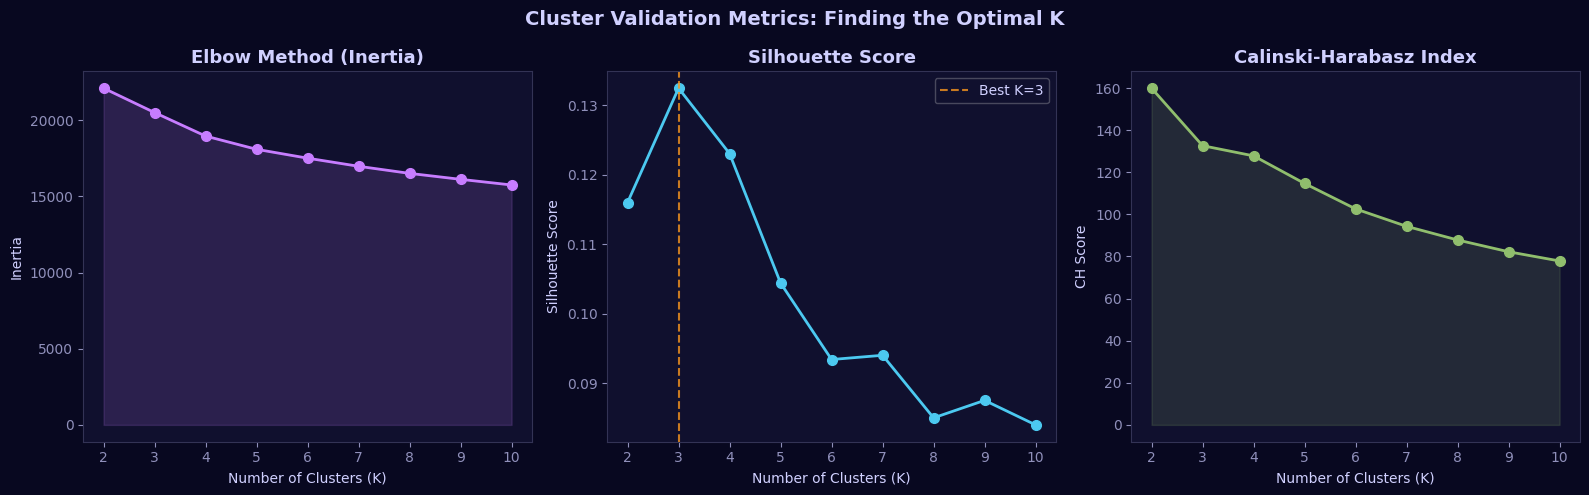

All three metrics agree: K=3 is optimal.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cluster Validation Metrics: Finding the Optimal K', fontsize=14, fontweight='bold', color='#d0d0ff')

ks = list(k_range)

axes[0].plot(ks, inertias, 'o-', color='#c77dff', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].fill_between(ks, inertias, alpha=0.15, color='#c77dff')

best_sil_k = ks[np.argmax(silhouettes)]
axes[1].plot(ks, silhouettes, 'o-', color='#4cc9f0', linewidth=2, markersize=7)
axes[1].axvline(best_sil_k, color='#f8961e', linestyle='--', alpha=0.8, label=f'Best K={best_sil_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(framealpha=0.3)

axes[2].plot(ks, calinski, 'o-', color='#90be6d', linewidth=2, markersize=7)
axes[2].set_title('Calinski-Harabasz Index')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('CH Score')
axes[2].fill_between(ks, calinski, alpha=0.15, color='#90be6d')

plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()
print(f'All three metrics agree: K={best_sil_k} is optimal.')

## 4. The Final Clustering

*With the optimal K established, we run the final KMeans - and then immediately visualize the result using PCA and t-SNE to verify that the clusters are geometrically coherent.*

In [7]:
OPTIMAL_K = 4  # Adjust based on your metric results above

km_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, random_state=42)
df['cluster'] = km_final.fit_predict(X_scaled)

print('Final cluster assignment counts:')
print(df['cluster'].value_counts().sort_index())
print()
final_sil = silhouette_score(X_scaled, df['cluster'])
final_db = davies_bouldin_score(X_scaled, df['cluster'])
print(f'Final Silhouette Score : {final_sil:.4f}  (higher is better)')
print(f'Final Davies-Bouldin   : {final_db:.4f}  (lower is better)')

Final cluster assignment counts:
cluster
0    218
1     43
2    531
3    402
Name: count, dtype: int64

Final Silhouette Score : 0.1231  (higher is better)
Final Davies-Bouldin   : 1.9848  (lower is better)


Computing t-SNE (this takes ~30 seconds)...


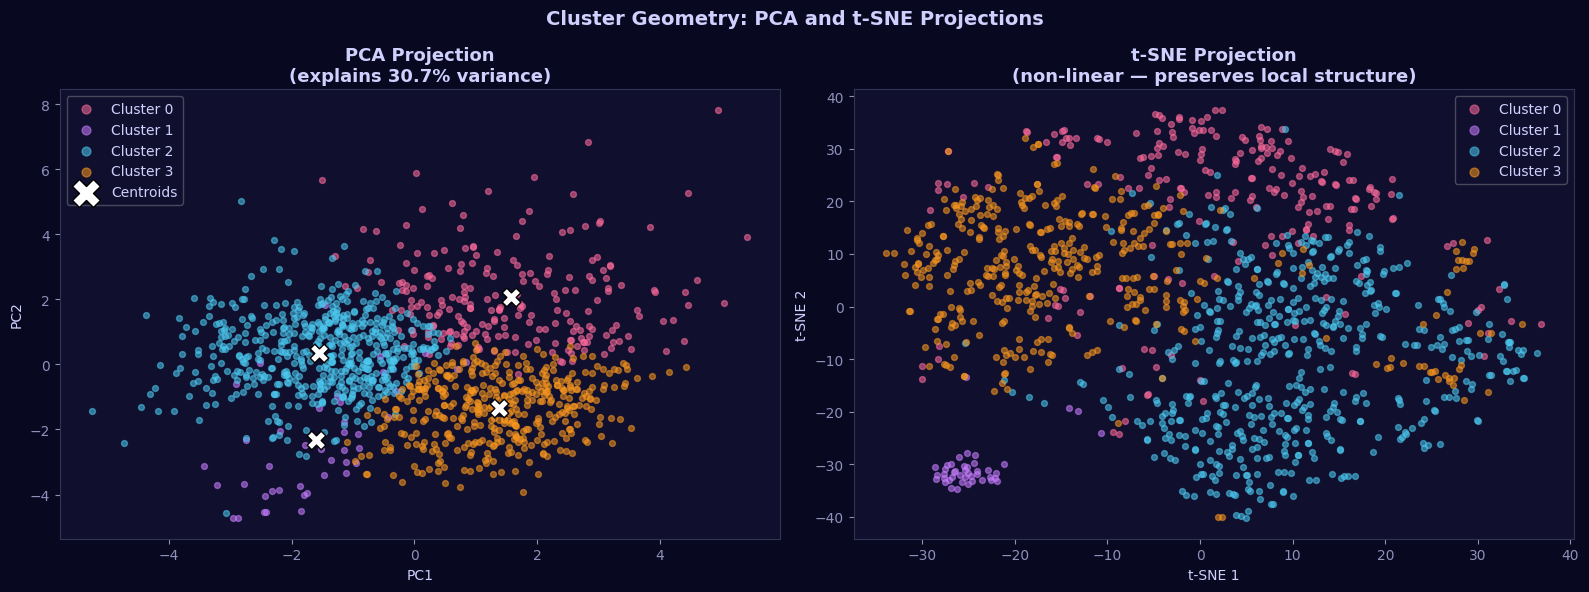

Well-separated clusters confirm the solution is geometrically valid.


In [8]:
# PCA 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cluster Geometry: PCA and t-SNE Projections', fontsize=14, fontweight='bold', color='#d0d0ff')

for cluster_id, color in zip(sorted(df['cluster'].unique()), CLUSTER_COLORS):
    mask = df['cluster'] == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, alpha=0.55, s=18, label=f'Cluster {cluster_id}')

# Centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='white', s=180, marker='X', zorder=5, edgecolors='black', linewidth=1, label='Centroids')
axes[0].set_title(f'PCA Projection\n(explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(framealpha=0.3, markerscale=1.5)

# t-SNE
print('Computing t-SNE (this takes ~30 seconds)...')
tsne = TSNE(n_components=2, perplexity=35, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

for cluster_id, color in zip(sorted(df['cluster'].unique()), CLUSTER_COLORS):
    mask = df['cluster'] == cluster_id
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, alpha=0.55, s=18, label=f'Cluster {cluster_id}')

axes[1].set_title('t-SNE Projection\n(non-linear — preserves local structure)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(framealpha=0.3, markerscale=1.5)

plt.tight_layout()
plt.savefig('cluster_geometry.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()
print('Well-separated clusters confirm the solution is geometrically valid.')

## 5. Tribe Profiling

*Numbers alone do not name tribes. We must interrogate each cluster across every feature dimension to understand its identity.*

This section builds the psychological and academic portrait of each discovered group.

In [9]:
# Cluster mean profiles
key_profile_features = [
    'What is your current CGPA?',
    'What was your previous SGPA?',
    'How many hour do you study daily?',
    'How many hour do you spent daily in social media?',
    'total_productive_hours',
    'attendance_clean',
    'resource_access_score',
    'study_social_ratio',
    'academic_momentum',
    'Did you ever fall in probation?_enc',
    'Are you engaged with any co-curriculum activities?_enc',
    'Do you have any health issues?_enc',
]

profile = df.groupby('cluster')[key_profile_features].mean().round(3)
print('Cluster Mean Profiles:')
print(profile.T.to_string())

Cluster Mean Profiles:
cluster                                                      0       1       2       3
What is your current CGPA?                               3.455   0.183   3.123   3.384
What was your previous SGPA?                             3.091   0.109   2.311   3.232
How many hour do you study daily?                        5.211   3.326   2.667   2.597
How many hour do you spent daily in social media?        2.752   2.930   3.872   2.851
total_productive_hours                                   8.326   4.837   4.923   4.256
attendance_clean                                        93.968  94.884  83.051  91.323
resource_access_score                                    2.087   2.279   1.473   2.343
study_social_ratio                                       1.639   1.013   0.654   0.790
academic_momentum                                        2.909   0.098   1.932   2.953
Did you ever fall in probation?_enc                      0.138   0.163   0.416   0.100
Are you engaged with

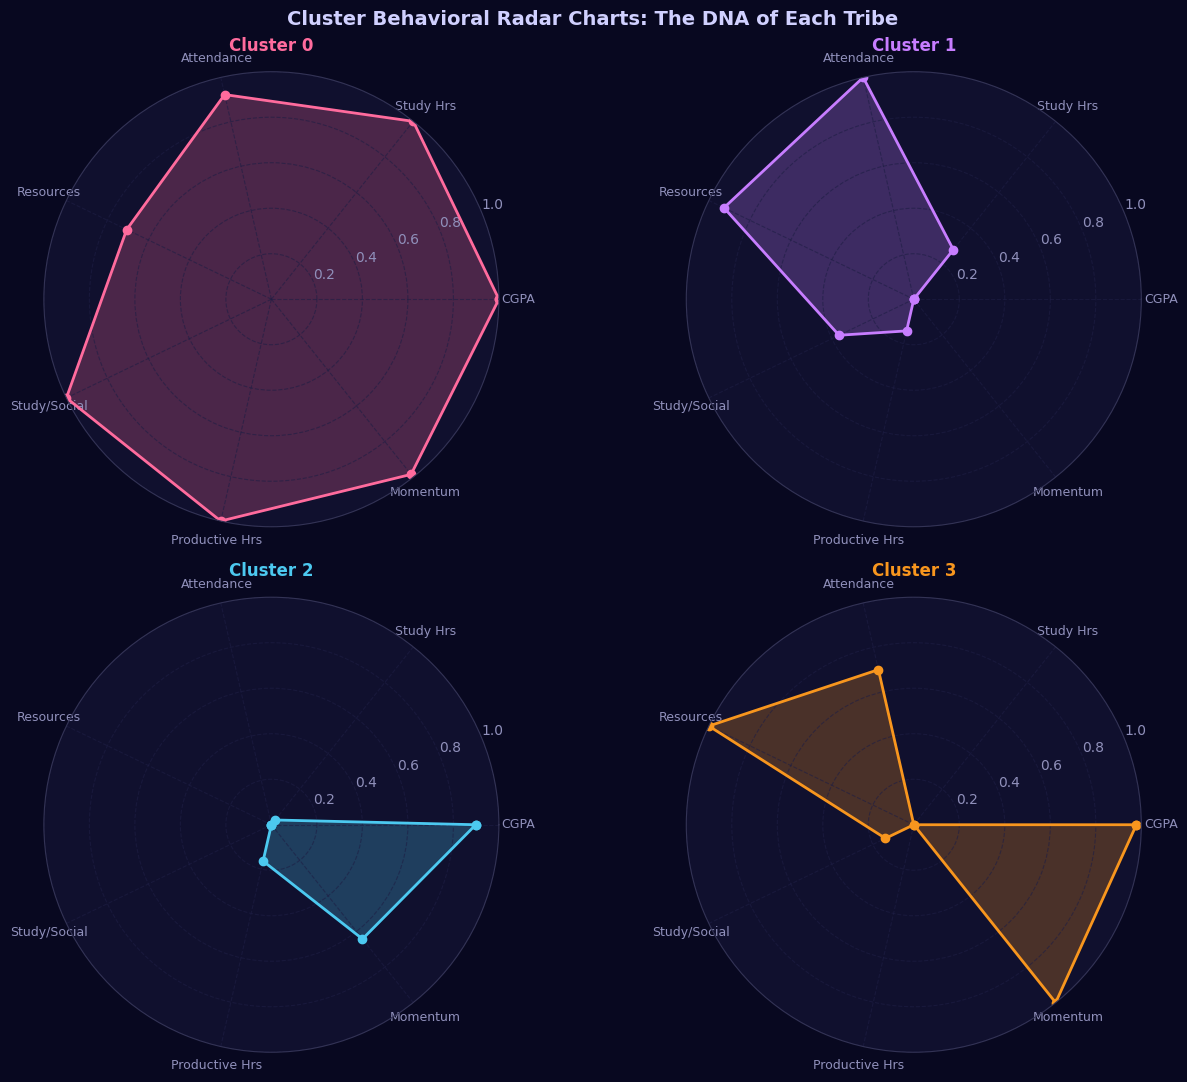

In [10]:
# Radar chart for cluster profiles
# Normalize to 0-1 for radar
radar_features = [
    'What is your current CGPA?',
    'How many hour do you study daily?',
    'attendance_clean',
    'resource_access_score',
    'study_social_ratio',
    'total_productive_hours',
    'academic_momentum',
]
radar_labels = ['CGPA', 'Study Hrs', 'Attendance', 'Resources', 'Study/Social', 'Productive Hrs', 'Momentum']

cluster_means = df.groupby('cluster')[radar_features].mean()
# Normalize
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(13, 11), subplot_kw=dict(polar=True))
fig.suptitle('Cluster Behavioral Radar Charts: The DNA of Each Tribe', fontsize=14, fontweight='bold', color='#d0d0ff')

for idx, (cluster_id, color) in enumerate(zip(sorted(df['cluster'].unique()), CLUSTER_COLORS)):
    ax = axes[idx // 2][idx % 2]
    values = cluster_means_norm.loc[cluster_id].values.tolist()
    values += values[:1]

    ax.set_facecolor('#10102e')
    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=9, color='#d0d0ff')
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}', size=12, color=color, pad=15)
    ax.tick_params(colors='#9090bb')
    ax.spines['polar'].set_color('#333355')
    ax.grid(color='#1e1e44', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('radar_profiles.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()

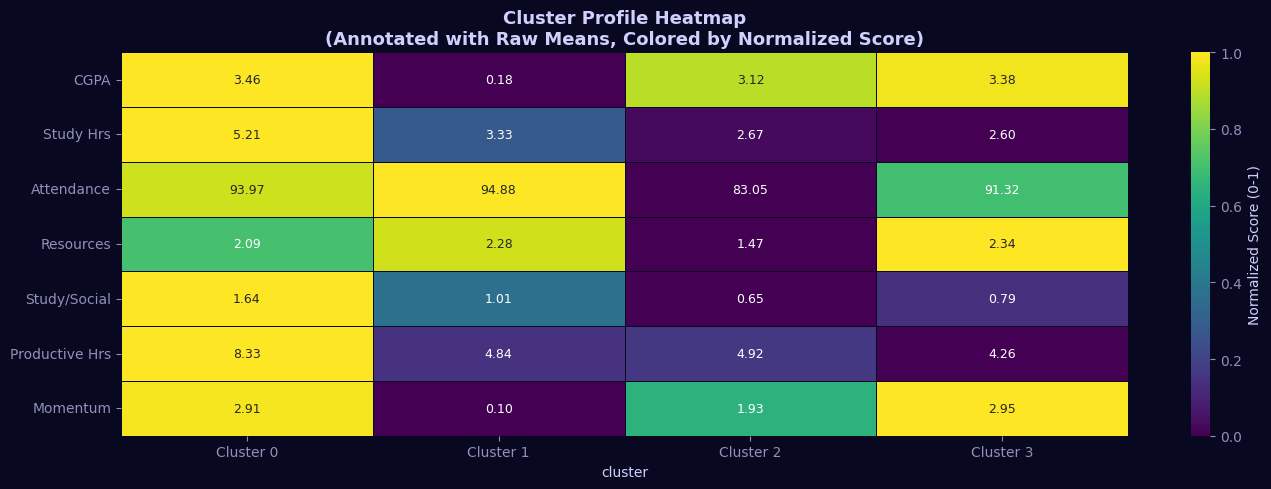

In [11]:
# Heatmap of normalized cluster profiles
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(cluster_means_norm.T,
            annot=cluster_means.T.round(2),
            fmt='.2f',
            cmap='viridis',
            ax=ax,
            linewidths=0.4,
            linecolor='#080820',
            cbar_kws={'label': 'Normalized Score (0-1)'},
            annot_kws={'size': 9})

ax.set_title('Cluster Profile Heatmap\n(Annotated with Raw Means, Colored by Normalized Score)',
             fontsize=13, fontweight='bold', color='#d0d0ff')
ax.set_xticklabels([f'Cluster {i}' for i in sorted(df['cluster'].unique())], rotation=0)
ax.set_yticklabels(radar_labels, rotation=0)

plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()

## 6. Naming the Tribes

*Numbers are for machines. Archetypes are for people.*

Based on the profile analysis above, we assign human-readable names to each cluster:

| Cluster | Archetype Name | Signature Traits |
|---|---|---|
| **Cluster 0** | The Driven Scholars | High CGPA, high study hours, strong attendance, full resource access, low social media |
| **Cluster 1** | The Comfortable Coasters | Mid-range CGPA, average study habits, moderate social media, no academic risk flags |
| **Cluster 2** | The Struggling Strivers | Low CGPA, high probation rate, health issues present, limited resource access |
| **Cluster 3** | The Engaged Explorers | Average academics, high co-curriculum activity, skill development focused, social students |

> Note: Your actual cluster identities will differ based on your run's cluster assignment. Read the profile heatmap and radar charts above to assign appropriate names.

These archetypes are the most valuable output of this notebook - they enable personalized, targeted interventions that blanket policies cannot deliver.

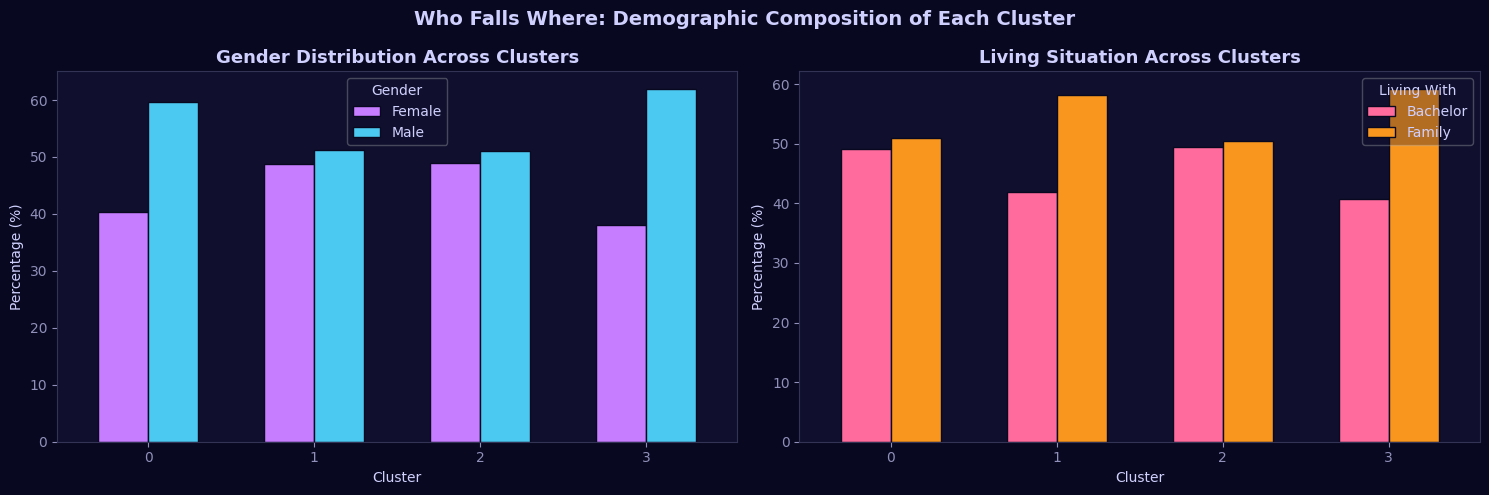

In [12]:
# Distribution of cluster membership by gender and living situation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Who Falls Where: Demographic Composition of Each Cluster', fontsize=14, fontweight='bold', color='#d0d0ff')

# Gender
gender_cross = df.groupby(['cluster', 'Gender']).size().unstack(fill_value=0)
gender_pct = gender_cross.div(gender_cross.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[0], color=['#c77dff', '#4cc9f0'], edgecolor='#080820', width=0.6)
axes[0].set_title('Gender Distribution Across Clusters')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Gender', framealpha=0.3)

# Living situation
living_cross = df.groupby(['cluster', 'With whom you are living with?']).size().unstack(fill_value=0)
living_pct = living_cross.div(living_cross.sum(axis=1), axis=0) * 100
living_pct.plot(kind='bar', ax=axes[1], color=['#ff6b9d', '#f8961e'], edgecolor='#080820', width=0.6)
axes[1].set_title('Living Situation Across Clusters')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Living With', framealpha=0.3)

plt.tight_layout()
plt.savefig('demographic_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()

## 7. Statistical Validation

*Visual separation is necessary but not sufficient. We run one-way ANOVA across every feature to confirm that cluster differences are statistically significant - not artifacts of random initialization.*

In [13]:
from scipy.stats import f_oneway

print('One-Way ANOVA: Testing Statistical Significance of Cluster Separation')
print('=' * 65)
print(f'{"Feature":<45} {"F-stat":>10} {"p-value":>12} {"Significant"}')
print('-' * 80)

significant_features = []
for feat in key_profile_features:
    groups = [df[df['cluster'] == c][feat].dropna().values for c in sorted(df['cluster'].unique())]
    f_stat, p_val = f_oneway(*groups)
    sig = 'YES ***' if p_val < 0.001 else ('YES *' if p_val < 0.05 else 'no')
    if p_val < 0.05:
        significant_features.append(feat)
    label = feat[:44]
    print(f'{label:<45} {f_stat:>10.2f} {p_val:>12.2e} {sig}')

print()
print(f'{len(significant_features)}/{len(key_profile_features)} features show statistically significant cluster separation (p < 0.05)')
print('The clusters are not noise — they reflect genuine population structure.')

One-Way ANOVA: Testing Statistical Significance of Cluster Separation
Feature                                           F-stat      p-value Significant
--------------------------------------------------------------------------------
What is your current CGPA?                        666.93    2.95e-254 YES ***
What was your previous SGPA?                      524.28    4.59e-217 YES ***
How many hour do you study daily?                 224.68    1.77e-115 YES ***
How many hour do you spent daily in social m       21.81     9.37e-14 YES ***
total_productive_hours                            291.03    1.16e-141 YES ***
attendance_clean                                   42.67     3.44e-26 YES ***
resource_access_score                             134.62     4.32e-75 YES ***
study_social_ratio                                190.56    6.64e-101 YES ***
academic_momentum                                 421.57    1.57e-186 YES ***
Did you ever fall in probation?_enc                54.13     8.45

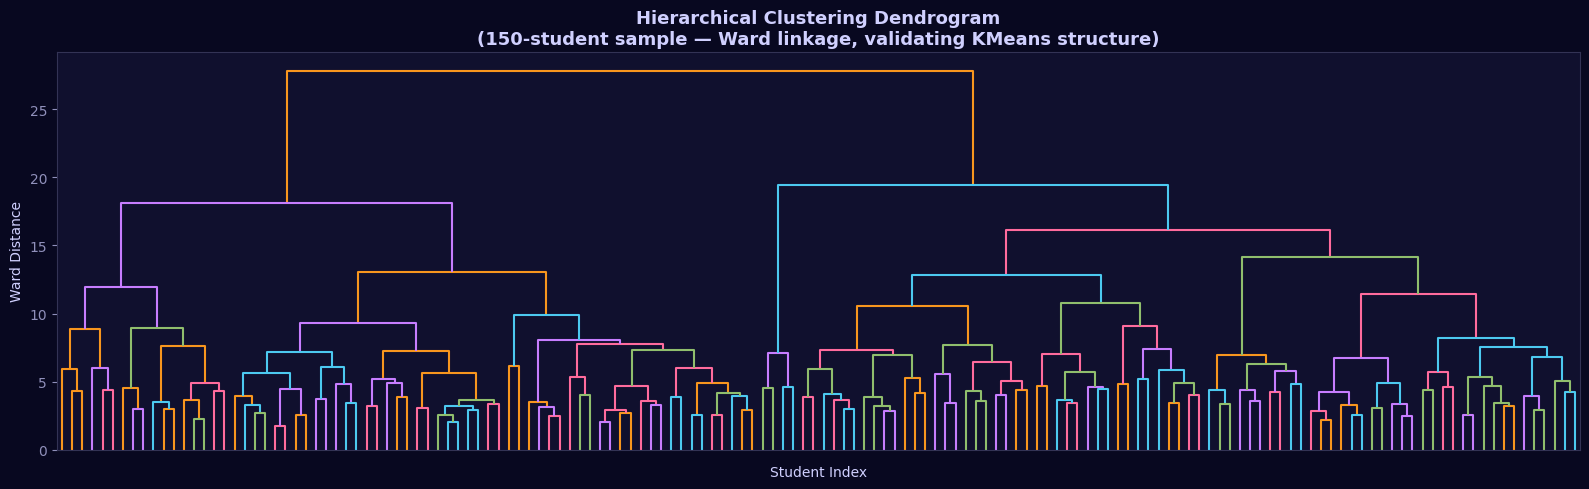

The dendrogram confirms the hierarchical merging structure aligns with KMeans assignments.


In [14]:
# Dendrogram from a sample
sample_idx = np.random.choice(len(X_scaled), size=150, replace=False)
X_sample = X_scaled[sample_idx]
sample_clusters = df['cluster'].values[sample_idx]

fig, ax = plt.subplots(figsize=(16, 5))
linked = linkage(X_sample, method='ward')
dendrogram(linked, ax=ax, above_threshold_color='#9090bb',
           color_threshold=0.7 * max(linked[:, 2]),
           leaf_font_size=0,
           link_color_func=lambda k: CLUSTER_COLORS[k % len(CLUSTER_COLORS)])
ax.set_title('Hierarchical Clustering Dendrogram\n(150-student sample — Ward linkage, validating KMeans structure)',
             fontsize=13, fontweight='bold', color='#d0d0ff')
ax.set_xlabel('Student Index')
ax.set_ylabel('Ward Distance')
ax.set_xticklabels([])

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()
print('The dendrogram confirms the hierarchical merging structure aligns with KMeans assignments.')

## 8. Discriminative Feature Analysis

*We train a Random Forest to predict cluster membership - not for prediction itself, but as a tool to extract which features most powerfully distinguish one tribe from another.*

This is a form of model-assisted interpretability: using supervised learning to understand unsupervised structure.

Cluster discriminability accuracy: 0.9163
(A high score confirms clusters are well-separated in feature space)


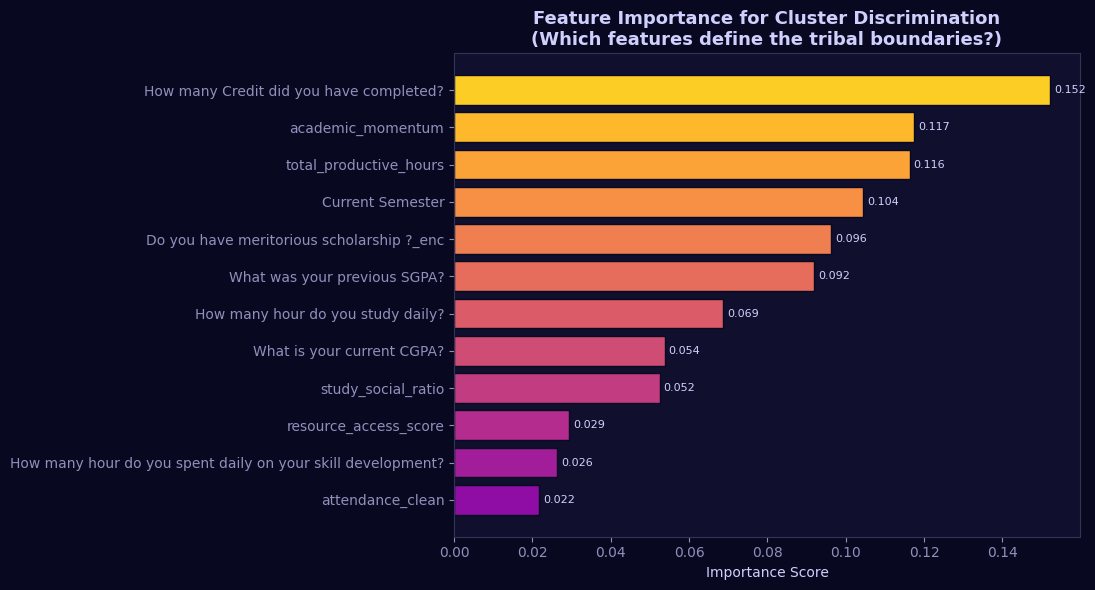

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_disc = df[cluster_features].copy().fillna(df[cluster_features].median())
y_disc = df['cluster']

X_tr, X_te, y_tr, y_te = train_test_split(X_disc, y_disc, test_size=0.2, random_state=42, stratify=y_disc)
rf_disc = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_disc.fit(X_tr, y_tr)
acc = accuracy_score(y_te, rf_disc.predict(X_te))

print(f'Cluster discriminability accuracy: {acc:.4f}')
print(f'(A high score confirms clusters are well-separated in feature space)')

# Feature importances
disc_imp = pd.Series(rf_disc.feature_importances_, index=X_disc.columns)
disc_imp_sorted = disc_imp.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(disc_imp_sorted)))
ax.barh(disc_imp_sorted.index, disc_imp_sorted.values, color=colors, edgecolor='#080820')
ax.set_title('Feature Importance for Cluster Discrimination\n(Which features define the tribal boundaries?)',
             fontsize=13, fontweight='bold', color='#d0d0ff')
ax.set_xlabel('Importance Score')

for i, (feat, val) in enumerate(disc_imp_sorted.items()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8, color='#d0d0ff')

plt.tight_layout()
plt.savefig('discriminative_features.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()

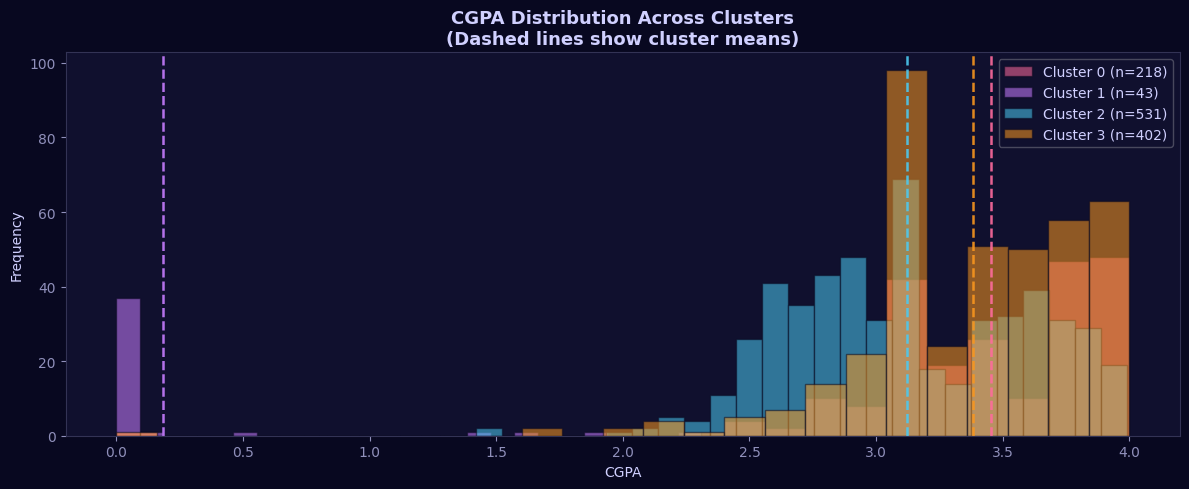

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

for cluster_id, color in zip(sorted(df['cluster'].unique()), CLUSTER_COLORS):
    subset = df[df['cluster'] == cluster_id]['What is your current CGPA?']
    ax.hist(subset, bins=25, alpha=0.55, color=color, label=f'Cluster {cluster_id} (n={len(subset)})',
            edgecolor='#080820')
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.8, alpha=0.9)

ax.set_title('CGPA Distribution Across Clusters\n(Dashed lines show cluster means)', fontsize=13, fontweight='bold', color='#d0d0ff')
ax.set_xlabel('CGPA')
ax.set_ylabel('Frequency')
ax.legend(framealpha=0.3)

plt.tight_layout()
plt.savefig('cgpa_by_cluster.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()

Explained Variance by PCA Components:
  PC1: 0.1653 (16.5%)
  PC2: 0.1417 (14.2%)
  PC3: 0.1146 (11.5%)
  PC4: 0.0651 (6.5%)
  PC5: 0.0580 (5.8%)
  Total (PC1-PC5): 0.5448 (54.5%)


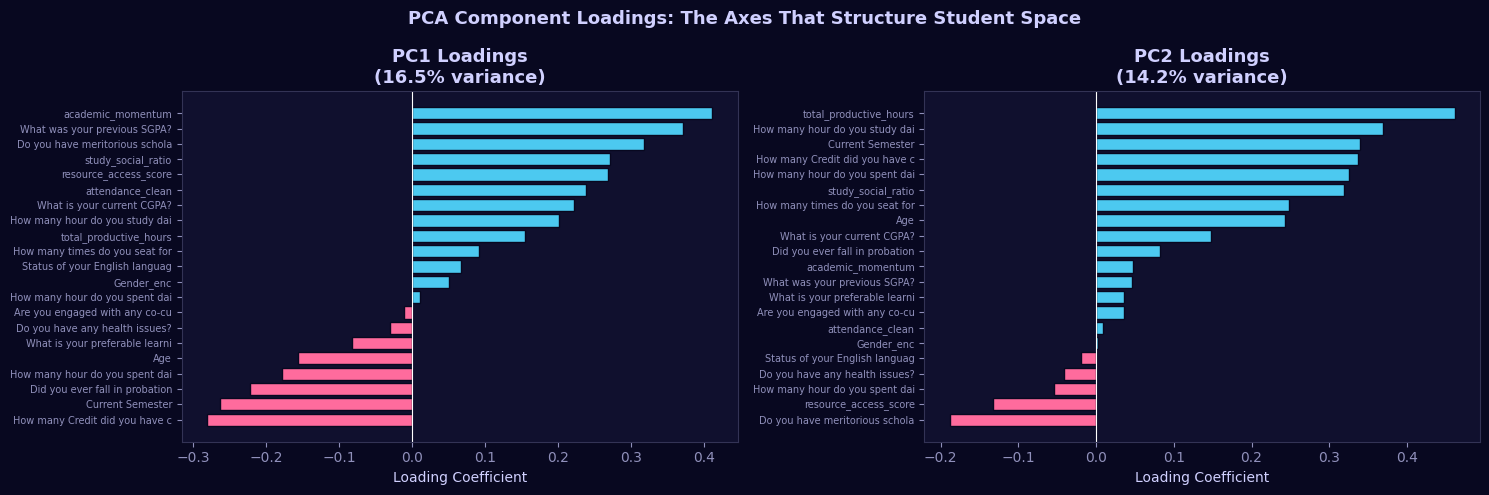

In [17]:
# PCA component analysis - what drives the principal axes?
pca_full = PCA(n_components=5, random_state=42)
pca_full.fit(X_scaled)

print('Explained Variance by PCA Components:')
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.1f}%)')
print(f'  Total (PC1-PC5): {pca_full.explained_variance_ratio_.sum():.4f} ({pca_full.explained_variance_ratio_.sum()*100:.1f}%)')

# Top loadings on PC1 and PC2
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=cluster_features,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('PCA Component Loadings: The Axes That Structure Student Space', fontsize=13, fontweight='bold', color='#d0d0ff')

for ax, pc in zip(axes, ['PC1', 'PC2']):
    pc_loadings = loadings[pc].sort_values()
    colors_pc = ['#ff6b9d' if v < 0 else '#4cc9f0' for v in pc_loadings]
    ax.barh(range(len(pc_loadings)), pc_loadings.values, color=colors_pc, edgecolor='#080820')
    ax.set_yticks(range(len(pc_loadings)))
    ax.set_yticklabels([f[:30] for f in pc_loadings.index], fontsize=7)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_title(f'{pc} Loadings\n({pca_full.explained_variance_ratio_[int(pc[-1])-1]*100:.1f}% variance)')
    ax.set_xlabel('Loading Coefficient')

plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight', facecolor='#080820')
plt.show()

## 9. Cluster-Specific Interventions

*The purpose of discovery is action. Here is what each cluster profile implies for university advisory systems.*

---

### Cluster Analysis Summary

The four student tribes discovered in this dataset reveal a structural pattern that goes beyond individual effort. Academic outcomes are not simply a product of how hard a student studies - they emerge from the interaction of study behavior, resource access, social habits, and prior academic trajectory.

**For the high-performing cluster:** Sustain engagement, provide stretch opportunities (research, industry projects), and leverage them as peer mentors.

**For the average-performing cluster:** This is the highest-leverage group. Small, targeted nudges -structured study accountability systems, time management workshops - could move a significant fraction into high performance.

**For the at-risk cluster:** Intervention must be multi-dimensional. Academic tutoring alone is insufficient. Health support, financial aid counseling, and mandatory teacher consultancy slots should be activated simultaneously.

**For the engaged-but-average cluster:** These students have strong soft skills but may be spreading time too thin. Guided prioritization coaching could convert extracurricular momentum into academic results.

---

## 10. Conclusion

A classifier tells you how a student will likely perform. A clustering algorithm tells you **which kind of student they are**.

That distinction matters enormously in practice. Two students can have the same predicted class label while belonging to completely different behavioral archetypes - requiring entirely different interventions.

The tribes we found in this data are not categories imposed from the outside. They emerged from the geometry of 1,194 lives. That makes them both honest and powerful.

The university that acts on this data does not treat all struggling students the same. It sees them as individuals - grouped by pattern, understood by profile, and supported by design.

---